# 完整分割与边界点输出演示

基于 patient0200 的点标注，进行完整的 MedSAM 分割推理，并同时提取和可视化边界点（伪标注）。

流程：
1. 加载点标注与超声图像
2. 加载 MedSAM 模型
3. 推理分割（生成预测 mask）
4. 从 mask 提取边缘强度图
5. 生成边界点（伪标注）
6. 可视化：分割结果 + 边界点 + 边缘强度图

In [28]:
import numpy as np
import torch
import cv2
from pathlib import Path
from matplotlib import pyplot as plt
from torch.nn import functional as F
from segment_anything import sam_model_registry
import nibabel as nib

# ============ 辅助函数 ============

def _load_point_npz(npz_path: Path):
    data = np.load(npz_path)
    coords = data["point_coords"]
    labels = data["point_labels"]
    if coords is None:
        coords = data[data.files[0]]
    if labels is None:
        labels = np.ones((coords.shape[0],), dtype=np.int64)
    return coords, labels

def _preprocess_image_for_sam(image: np.ndarray, device: torch.device):
    if image.ndim == 2:
        image_rgb = np.repeat(image[:, :, None], 3, axis=2)
    else:
        image_rgb = image
    image_rgb = image_rgb.astype(np.float32)
    if image_rgb.max() > 1.0:
        image_rgb = image_rgb / 255.0
    image_resized = cv2.resize(image_rgb, (1024, 1024), interpolation=cv2.INTER_CUBIC)
    image_tensor = torch.tensor(image_resized).permute(2, 0, 1).unsqueeze(0).to(device)
    return image_tensor, image_rgb


In [29]:
# ============ 加载数据 ============
base_dir = Path(r"d:\HP\OneDrive\Desktop\学校\项目\超声图分割")
img_path = base_dir / "resource" / "数据处理" / "point_annotations" / "imgs" / "patient0200_patient0200_2CH_ED.npy"
pt_path = base_dir / "resource" / "数据处理" / "point_annotations" / "pts" / "patient0200_patient0200_2CH_ED.npz"

assert img_path.exists(), f"图像不存在: {img_path}"
assert pt_path.exists(), f"点标注不存在: {pt_path}"

image = np.load(img_path)
coords, labels = _load_point_npz(pt_path)
H, W = image.shape[:2]

print(f"✓ 图像加载: shape={image.shape}, dtype={image.dtype}")
print(f"✓ 点标注加载: coords shape={coords.shape}, labels shape={labels.shape}")
print(f"  前3个点: {coords[:3]}")

✓ 图像加载: shape=(590, 487), dtype=float64
✓ 点标注加载: coords shape=(3, 2), labels shape=(3,)
  前3个点: [[227 322]
 [157 242]
 [326 351]]


In [30]:
# ============ 加载 MedSAM 模型 ============
medsam_ckpt_path = base_dir / "MedSAM" / "work_dir" / "camus_point" / "medsam_point_prompt_best.pth"
medsam_pretrained_path = base_dir / "MedSAM" / "work_dir" / "MedSAM" / "medsam_vit_b.pth"

assert medsam_ckpt_path.exists(), f"权重不存在: {medsam_ckpt_path}"
assert medsam_pretrained_path.exists(), f"预训练权重不存在: {medsam_pretrained_path}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ 使用设备: {device}")

sam_model = sam_model_registry["vit_b"](checkpoint=str(medsam_pretrained_path))
checkpoint = torch.load(str(medsam_ckpt_path), map_location=device)
sam_model.load_state_dict(checkpoint["model"], strict=False)
sam_model = sam_model.to(device)
sam_model.eval()

print(f"✓ MedSAM 模型加载成功")

✓ 使用设备: cuda
✓ MedSAM 模型加载成功


In [31]:
# ============ 完整推理流程 ============
with torch.no_grad():
    image_tensor, image_rgb = _preprocess_image_for_sam(image, device)
    image_embeddings = sam_model.image_encoder(image_tensor)
    print(f"✓ 图像编码完成: embeddings shape = {image_embeddings.shape}")

# 处理坐标（若需要缩放到像素坐标）
coords_use = coords[:3].copy()
if coords_use.max() <= 1.0:
    coords_use[:, 0] = coords_use[:, 0] * W
    coords_use[:, 1] = coords_use[:, 1] * H

labels_use = labels[:3]

def _infer_one_point(x, y, label=1):
    """推理单个点的分割"""
    coords_1024 = np.array([[[x * 1024 / W, y * 1024 / H]]], dtype=np.float32)
    coords_torch = torch.tensor(coords_1024, dtype=torch.float32, device=device)
    labels_torch = torch.tensor([[int(label)]], dtype=torch.long, device=device)
    
    sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
        points=(coords_torch, labels_torch),
        boxes=None,
        masks=None,
    )
    
    low_res_logits, _ = sam_model.mask_decoder(
        image_embeddings=image_embeddings,
        image_pe=sam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )
    
    low_res_probs = torch.sigmoid(low_res_logits)
    pred = F.interpolate(low_res_probs, size=(H, W), mode="bilinear", align_corners=False)
    pred = pred.detach().cpu().numpy().squeeze()
    mask = (pred > 0.5).astype(np.uint8)
    logits = pred  # 保存原始 logits（用于边缘检测）
    return mask, logits

# 对每个点进行推理
masks_pred = []
logits_pred = []
for i, (x, y) in enumerate(coords_use):
    mask, logits = _infer_one_point(float(x), float(y), labels_use[i])
    masks_pred.append(mask)
    logits_pred.append(logits)
    print(f"✓ Point {i+1} ({x:.1f}, {y:.1f}): mask shape={mask.shape}, foreground={np.sum(mask)} pixels")

print(f"\n✓ 推理完成，共 {len(masks_pred)} 个分割结果")

✓ 图像编码完成: embeddings shape = torch.Size([1, 256, 64, 64])
✓ Point 1 (227.0, 322.0): mask shape=(590, 487), foreground=24376 pixels
✓ Point 2 (157.0, 242.0): mask shape=(590, 487), foreground=28449 pixels
✓ Point 3 (326.0, 351.0): mask shape=(590, 487), foreground=9182 pixels

✓ 推理完成，共 3 个分割结果


In [32]:
# ============ 步骤 1 & 2: 边缘强度图 + 边界点生成（无距离阈值版本） ============

def edge_strength_from_logits(logits):
    """从 logits 计算边缘强度图"""
    gy, gx = np.gradient(logits)
    edge = np.sqrt(gx**2 + gy**2)
    if edge.max() > 0:
        edge = (edge - edge.min()) / (edge.max() - edge.min())
    return edge

def calculate_local_contrast(edge_map, pts, window_size=5):
    """
    计算每个点的局部对比度（基于局部方差）
    
    Args:
        edge_map: 边缘强度图
        pts: (N, 2) 候选点坐标 [x, y]
        window_size: 局部窗口大小
    """
    H, W = edge_map.shape
    half_win = window_size // 2
    local_contrasts = []
    
    for x, y in pts:
        # 提取局部窗口
        y_min = max(0, y - half_win)
        y_max = min(H, y + half_win + 1)
        x_min = max(0, x - half_win)
        x_max = min(W, x + half_win + 1)
        
        patch = edge_map[y_min:y_max, x_min:x_max]
        
        # 计算局部方差（对比度）
        if patch.size > 0:
            local_var = patch.var()
        else:
            local_var = 0.0
        
        local_contrasts.append(local_var)
    
    return np.array(local_contrasts)

def generate_boundary_points_no_dist(edge_map, max_points=300, edge_percentile=85, contrast_percentile=50, weight_edge=0.6, weight_contrast=0.4):
    """
    从边缘强度图生成边界点（无距离阈值版本）
    
    仅基于：
    1. 边缘强度高（来自 logits 梯度）
    2. 局部对比度高（局部方差）
    
    Args:
        edge_map: 边缘强度图
        max_points: 最多保留的点数
        edge_percentile: 边缘强度百分位阈值
        contrast_percentile: 局部对比度百分位阈值
        weight_edge: 边缘强度权重
        weight_contrast: 局部对比度权重
    """
    H, W = edge_map.shape
    
    # 1) 边缘强度筛选：保留高边缘强度候选点
    edge_thr = np.percentile(edge_map, edge_percentile)
    ys, xs = np.where(edge_map >= edge_thr)
    
    if len(xs) == 0:
        print(f"    ⚠ 未找到满足边缘阈值 {edge_thr:.4f} 的点")
        return np.zeros((0, 2), dtype=np.int32), np.zeros(0)
    
    print(f"  边缘筛选（≥{edge_percentile}%位）: {len(xs)} 个候选点")
    
    # 2) 计算局部对比度
    pts = np.stack([xs, ys], axis=1)  # (N, 2) [x, y]
    local_contrasts = calculate_local_contrast(edge_map, pts)
    
    # 3) 局部对比度筛选
    contrast_thr = np.percentile(local_contrasts, contrast_percentile)
    keep_contrast = local_contrasts >= contrast_thr
    
    pts_filtered = pts[keep_contrast]
    edge_scores = edge_map[ys[keep_contrast], xs[keep_contrast]]
    contrast_scores = local_contrasts[keep_contrast]
    
    print(f"  对比度筛选（≥{contrast_percentile}%位）: {len(pts_filtered)} 个点")
    
    if len(pts_filtered) == 0:
        print(f"    ⚠ 对比度筛选后无点保留")
        return np.zeros((0, 2), dtype=np.int32), np.zeros(0)
    
    # 4) 综合评分：加权组合边缘强度和局部对比度
    # 归一化
    edge_norm = (edge_scores - edge_scores.min()) / (edge_scores.max() - edge_scores.min() + 1e-7)
    contrast_norm = (contrast_scores - contrast_scores.min()) / (contrast_scores.max() - contrast_scores.min() + 1e-7)
    
    # 综合置信度
    combined_scores = weight_edge * edge_norm + weight_contrast * contrast_norm
    
    # 5) 按置信度排序，取 top-k
    if len(pts_filtered) > max_points:
        top_indices = np.argsort(combined_scores)[-max_points:]
        pts_filtered = pts_filtered[top_indices]
        combined_scores = combined_scores[top_indices]
        print(f"  置信度排序取 top-{max_points}")
    
    return pts_filtered.astype(np.int32), combined_scores

# 对每个分割结果提取边界点
all_boundary_points = []
all_edge_maps = []

print("\n边界点生成过程（无距离阈值）：\n" + "="*60)

for i, (logits, mask, base_pt) in enumerate(zip(logits_pred, masks_pred, coords_use)):
    edge_map = edge_strength_from_logits(logits)
    all_edge_maps.append(edge_map)
    
    print(f"\n【Point {i+1}】")
    
    # 使用无距离阈值算法生成边界点
    boundary_pts, boundary_confs = generate_boundary_points_no_dist(
        edge_map,
        max_points=300,
        edge_percentile=85,      # 边缘强度阈值
        contrast_percentile=50,  # 局部对比度阈值
        weight_edge=0.6,         # 边缘权重
        weight_contrast=0.4      # 对比度权重
    )
    all_boundary_points.append((boundary_pts, boundary_confs))
    
    if len(boundary_pts) > 0:
        print(f"  ✓ 最终生成: {len(boundary_pts)} 个边界点")
        print(f"  综合置信度: min={boundary_confs.min():.4f}, mean={boundary_confs.mean():.4f}, max={boundary_confs.max():.4f}")
    else:
        print(f"  ✗ 未生成边界点")

print("\n" + "="*60)
print(f"✓ 边界点生成完成\n")


边界点生成过程（无距离阈值）：

【Point 1】
  边缘筛选（≥85%位）: 43100 个候选点
  对比度筛选（≥50%位）: 21550 个点
  置信度排序取 top-300
  ✓ 最终生成: 300 个边界点
  综合置信度: min=0.2710, mean=0.4092, max=0.9127

【Point 2】
  边缘筛选（≥85%位）: 43100 个候选点
  对比度筛选（≥50%位）: 21550 个点
  置信度排序取 top-300
  ✓ 最终生成: 300 个边界点
  综合置信度: min=0.4513, mean=0.5659, max=0.9319

【Point 3】
  边缘筛选（≥85%位）: 43100 个候选点
  对比度筛选（≥50%位）: 21550 个点
  置信度排序取 top-300
  ✓ 最终生成: 300 个边界点
  综合置信度: min=0.3262, mean=0.4480, max=0.8164

✓ 边界点生成完成



In [33]:
# ============ 步骤 3 & 4: 边界置信度 + 可视化 ============

def calculate_boundary_confidence(edge_map, boundary_pts, base_pt, weight_gradient=0.5, weight_dist=0.3, weight_local_contrast=0.2):
    """计算每个边界点的置信度"""
    if len(boundary_pts) == 0:
        return np.array([])
    
    # 归一化边缘强度作为梯度权重
    grad_strength = edge_map[boundary_pts[:, 1], boundary_pts[:, 0]]
    grad_norm = (grad_strength - grad_strength.min()) / (grad_strength.max() - grad_strength.min() + 1e-7)
    
    # 距离权重：靠近原始点更高
    dist = np.linalg.norm(boundary_pts - base_pt[None, :], axis=1)
    max_dist = 20  # 阈值
    dist_norm = np.clip(1 - dist / max_dist, 0, 1)
    
    # 局部对比度权重（简化：使用局部方差）
    local_var = np.zeros(len(boundary_pts))
    for idx, (x, y) in enumerate(boundary_pts):
        patch = edge_map[max(0, y-3):min(edge_map.shape[0], y+4), max(0, x-3):min(edge_map.shape[1], x+4)]
        local_var[idx] = patch.var() if len(patch) > 0 else 0
    contrast_norm = (local_var - local_var.min()) / (local_var.max() - local_var.min() + 1e-7)
    
    # 加权置信度
    confidence = (
        weight_gradient * grad_norm +
        weight_dist * dist_norm +
        weight_local_contrast * contrast_norm
    )
    return confidence

# 计算所有边界点的置信度
all_confidences = []
for i, (boundary_pts, _) in enumerate(all_boundary_points):
    conf = calculate_boundary_confidence(all_edge_maps[i], boundary_pts, coords_use[i])
    all_confidences.append(conf)

print(f"✓ 边界置信度计算完成")

✓ 边界置信度计算完成


In [34]:

# ============ 调试：分析边界点为何为 0 ============

print("\n" + "="*70)
print("调试：边界点生成分析")
print("="*70 + "\n")

for i, (edge_map, mask, base_pt, (boundary_pts, _)) in enumerate(zip(all_edge_maps, masks_pred, coords_use, all_boundary_points)):
    print(f"\n【Point {i+1} 详细分析】")
    print(f"基础点位置: ({base_pt[0]:.1f}, {base_pt[1]:.1f})")
    print(f"分割 mask: 前景={np.sum(mask)} 像素 ({np.sum(mask)/(H*W)*100:.2f}%)")
    
    # 边缘强度统计
    print(f"\n边缘强度统计:")
    print(f"  最小值: {edge_map.min():.6f}")
    print(f"  Q10: {np.percentile(edge_map, 10):.6f}")
    print(f"  Q50: {np.percentile(edge_map, 50):.6f}")
    print(f"  Q90: {np.percentile(edge_map, 90):.6f}")
    print(f"  Q95: {np.percentile(edge_map, 95):.6f}")
    print(f"  最大值: {edge_map.max():.6f}")
    
    # 候选点统计
    cand_thr = np.percentile(edge_map, 90)
    cand_pts = np.where(edge_map >= cand_thr)
    print(f"\n候选边缘点（Q90={cand_thr:.6f}）:")
    print(f"  数量: {len(cand_pts[0])}")
    if len(cand_pts[0]) > 0:
        cand_xy = np.stack([cand_pts[1], cand_pts[0]], axis=1)
        dist_to_base = np.linalg.norm(cand_xy - base_pt[None, :], axis=1)
        print(f"  到基础点的距离: min={dist_to_base.min():.1f}, max={dist_to_base.max():.1f}, mean={dist_to_base.mean():.1f}")
        
        # 统计不同距离范围内的点数
        for d_range in [6, 10, 15, 20, 30, 50]:
            count = np.sum(dist_to_base <= d_range)
            print(f"    距离 ≤ {d_range}: {count} 个点")
    
    print(f"\n边界点输出: {len(boundary_pts)} 个")

print("\n" + "="*70)


调试：边界点生成分析


【Point 1 详细分析】
基础点位置: (227.0, 322.0)
分割 mask: 前景=24376 像素 (8.48%)

边缘强度统计:
  最小值: 0.000000
  Q10: 0.000004
  Q50: 0.000069
  Q90: 0.033936
  Q95: 0.076175
  最大值: 1.000000

候选边缘点（Q90=0.033936）:
  数量: 28733
  到基础点的距离: min=0.0, max=200.0, mean=102.7
    距离 ≤ 6: 24 个点
    距离 ≤ 10: 44 个点
    距离 ≤ 15: 100 个点
    距离 ≤ 20: 147 个点
    距离 ≤ 30: 222 个点
    距离 ≤ 50: 1250 个点

边界点输出: 300 个

【Point 2 详细分析】
基础点位置: (157.0, 242.0)
分割 mask: 前景=28449 像素 (9.90%)

边缘强度统计:
  最小值: 0.000000
  Q10: 0.000000
  Q50: 0.000040
  Q90: 0.080545
  Q95: 0.150035
  最大值: 1.000000

候选边缘点（Q90=0.080545）:
  数量: 28733
  到基础点的距离: min=4.2, max=268.7, mean=132.7
    距离 ≤ 6: 5 个点
    距离 ≤ 10: 25 个点
    距离 ≤ 15: 120 个点
    距离 ≤ 20: 323 个点
    距离 ≤ 30: 944 个点
    距离 ≤ 50: 3159 个点

边界点输出: 300 个

【Point 3 详细分析】
基础点位置: (326.0, 351.0)
分割 mask: 前景=9182 像素 (3.20%)

边缘强度统计:
  最小值: 0.000000
  Q10: 0.000002
  Q50: 0.000040
  Q90: 0.008691
  Q95: 0.027982
  最大值: 1.000000

候选边缘点（Q90=0.008691）:
  数量: 28733
  到基础点的距离: min=15.0, ma

✓ 结果图保存到: 完整推理结果.png


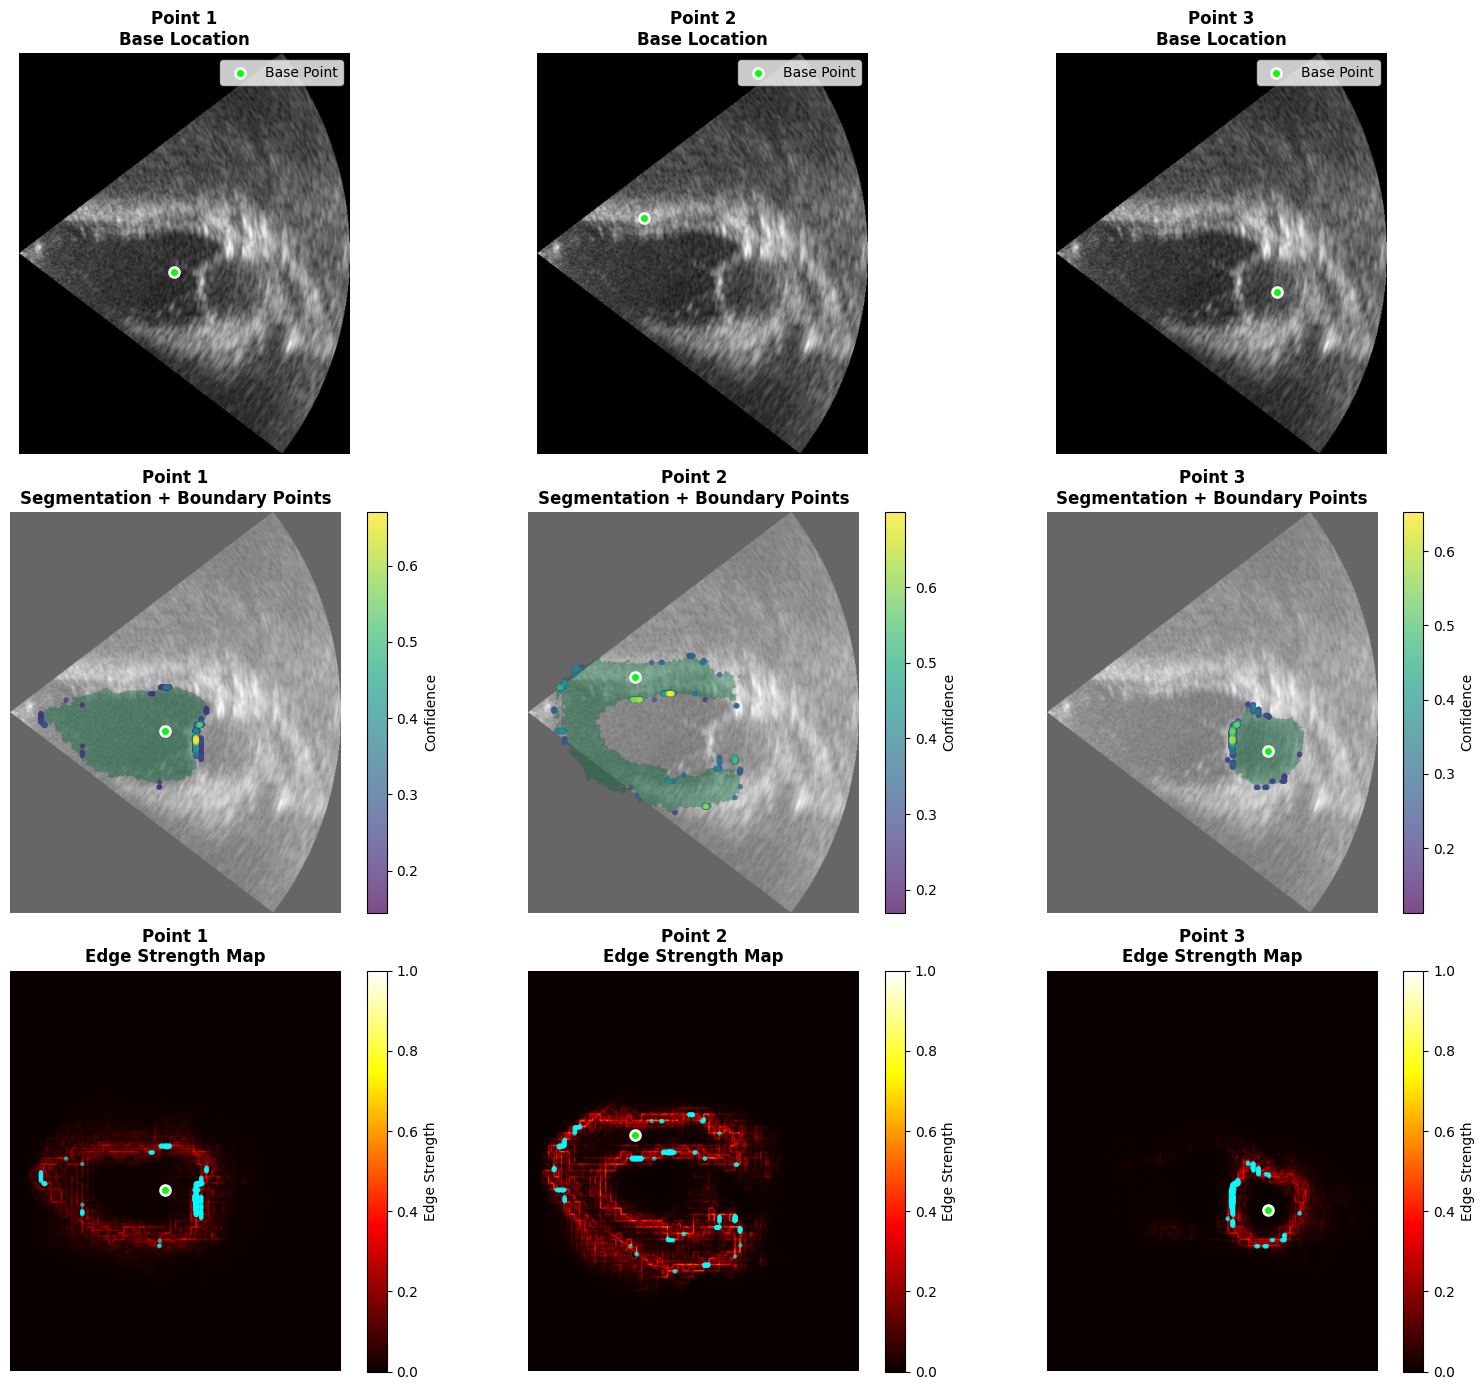

In [35]:
# ============ 可视化：3 行 3 列 ============
# 第 1 行：原始图像 + 基础点
# 第 2 行：分割 mask + 边界点
# 第 3 行：边缘强度图 + 置信度热力图

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for i in range(3):
    # ========== 第 1 行：原始图像 + 基础点 ==========
    ax = axes[0, i]
    ax.imshow(image, cmap="gray")
    ax.scatter(coords_use[i, 0], coords_use[i, 1], s=50, c="lime", marker="o", edgecolors="white", linewidth=2, label="Base Point")
    ax.set_title(f"Point {i+1}\nBase Location", fontsize=12, fontweight="bold")
    ax.legend(loc="upper right")
    ax.axis("off")
    
    # ========== 第 2 行：分割 mask + 边界点 ==========
    ax = axes[1, i]
    ax.imshow(image, cmap="gray", alpha=0.6)
    
    # 叠加 mask
    mask_vis = np.ma.masked_where(masks_pred[i] == 0, masks_pred[i])
    ax.imshow(mask_vis, alpha=0.4, cmap="RdYlGn", vmin=0, vmax=1)
    
    # 绘制边界点
    boundary_pts, _ = all_boundary_points[i]
    if len(boundary_pts) > 0:
        conf = all_confidences[i]
        scatter = ax.scatter(boundary_pts[:, 0], boundary_pts[:, 1], s=15, c=conf, cmap="viridis", alpha=0.7, edgecolors="none")
        fig.colorbar(scatter, ax=ax, label="Confidence")
    
    ax.scatter(coords_use[i, 0], coords_use[i, 1], s=50, c="lime", marker="o", edgecolors="white", linewidth=2)
    ax.set_title(f"Point {i+1}\nSegmentation + Boundary Points", fontsize=12, fontweight="bold")
    ax.axis("off")
    
    # ========== 第 3 行：边缘强度图 + 置信度分布 ==========
    ax = axes[2, i]
    edge_map = all_edge_maps[i]
    im = ax.imshow(edge_map, cmap="hot")
    fig.colorbar(im, ax=ax, label="Edge Strength")
    
    # 标注边界点位置
    boundary_pts, _ = all_boundary_points[i]
    if len(boundary_pts) > 0:
        conf = all_confidences[i]
        scatter = ax.scatter(boundary_pts[:, 0], boundary_pts[:, 1], s=10, c="cyan", alpha=0.6, edgecolors="none")
    
    ax.scatter(coords_use[i, 0], coords_use[i, 1], s=50, c="lime", marker="o", edgecolors="white", linewidth=2)
    ax.set_title(f"Point {i+1}\nEdge Strength Map", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(base_dir / "MedSAM" / "extensions" / "边界感知点标注增强" / "完整推理结果.png", dpi=150, bbox_inches="tight")
print(f"✓ 结果图保存到: 完整推理结果.png")
plt.show()

In [36]:
# ============ 统计与输出 ============
print("\n" + "="*70)
print("完整分割与边界点提取 - 统计摘要")
print("="*70)

print(f"\n图像信息：")
print(f"  分辨率: {H}x{W}")
print(f"  点标注数: {len(coords)}")

print(f"\n分割结果（前3个点）：")
for i in range(3):
    foreground = np.sum(masks_pred[i])
    ratio = foreground / (H * W) * 100
    print(f"  Point {i+1} at ({coords_use[i, 0]:.1f}, {coords_use[i, 1]:.1f}):")
    print(f"    前景像素: {foreground} ({ratio:.2f}%)")

print(f"\n边界点统计：")
for i in range(3):
    boundary_pts, _ = all_boundary_points[i]
    conf = all_confidences[i]
    if len(boundary_pts) > 0:
        print(f"  Point {i+1}:")
        print(f"    生成点数: {len(boundary_pts)}")
        print(f"    置信度: min={conf.min():.4f}, mean={conf.mean():.4f}, max={conf.max():.4f}")
    else:
        print(f"  Point {i+1}: 未生成边界点")

print(f"\n边缘强度图统计：")
for i in range(3):
    edge = all_edge_maps[i]
    print(f"  Point {i+1}: min={edge.min():.4f}, mean={edge.mean():.4f}, max={edge.max():.4f}")

print("\n" + "="*70)


完整分割与边界点提取 - 统计摘要

图像信息：
  分辨率: 590x487
  点标注数: 3

分割结果（前3个点）：
  Point 1 at (227.0, 322.0):
    前景像素: 24376 (8.48%)
  Point 2 at (157.0, 242.0):
    前景像素: 28449 (9.90%)
  Point 3 at (326.0, 351.0):
    前景像素: 9182 (3.20%)

边界点统计：
  Point 1:
    生成点数: 300
    置信度: min=0.1447, mean=0.2857, max=0.6703
  Point 2:
    生成点数: 300
    置信度: min=0.1693, mean=0.3767, max=0.7000
  Point 3:
    生成点数: 300
    置信度: min=0.1133, mean=0.2904, max=0.6528

边缘强度图统计：
  Point 1: min=0.0000, mean=0.0121, max=1.0000
  Point 2: min=0.0000, mean=0.0241, max=1.0000
  Point 3: min=0.0000, mean=0.0071, max=1.0000

